In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost
import catboost
import matplotlib.pyplot as plt

# Data collection

In [2]:
df_raw = pd.read_excel('for_analyses_kama_realistic.xlsx')

# удаляем нерелевантные признаки
df = df_raw.copy()
'''df.drop(columns=['reg_date', 'Аl3+','G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle'], 
            inplace=True)'''

df.drop(columns=['reg_date', 'G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle', 'uepp_end', 'SiO2_end'], 
        inplace=True)

df

,turb,pH,Аl3+,Alkal,hardness,NO,Сl,SO2,Са2,Mg2_max,Na_K_max,Fe_total,total_sal,PO,SiO2,Sum_cations,Sum_anions
0,0.71,7.68,0.064,4.91,6.10,1.00,28.0,21.0,95.3,18.7,28.7,0.08,477.2,5.41,7.1,3.665874,3.078215
1,0.71,7.68,0.064,4.91,6.11,1.01,28.0,21.0,95.4,18.7,28.9,0.08,477.8,5.41,7.1,3.744814,3.068691
2,0.69,7.68,0.064,4.89,6.08,1.00,28.0,21.0,95.1,18.7,28.2,0.08,475.9,5.38,7.1,3.891562,3.267278
3,0.67,7.67,0.064,4.87,6.06,1.00,28.0,21.0,94.7,18.7,27.6,0.07,474.1,5.36,7.1,3.437979,2.816907
4,0.74,7.68,0.065,4.84,6.01,1.04,27.8,20.9,93.7,18.8,26.4,0.08,471.0,5.48,7.1,3.315000,2.730000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,11.43,7.43,0.340,0.57,0.60,2.80,17.6,13.5,8.6,3.4,27.1,0.18,90.0,13.57,4.6,2.957000,2.327000
107,11.34,7.42,0.338,0.57,0.60,2.80,17.2,13.3,8.6,3.4,26.3,0.18,88.9,13.51,4.5,2.965000,2.325000
108,10.95,7.42,0.328,0.57,0.60,2.76,17.0,13.1,8.6,3.4,26.1,0.17,88.7,13.25,4.5,2.707000,2.107000
109,10.29,7.42,0.311,0.57,0.60,2.69,17.0,13.1,8.6,3.4,26.2,0.17,88.7,12.80,4.6,2.983000,2.431000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   turb         111 non-null    float64
 1   pH           111 non-null    float64
 2   Аl3+         111 non-null    float64
 3   Alkal        111 non-null    float64
 4   hardness     111 non-null    float64
 5   NO           111 non-null    float64
 6   Сl           111 non-null    float64
 7   SO2          111 non-null    float64
 8   Са2          111 non-null    float64
 9   Mg2_max      111 non-null    float64
 10  Na_K_max     111 non-null    float64
 11  Fe_total     111 non-null    float64
 12  total_sal    111 non-null    float64
 13  PO           111 non-null    float64
 14  SiO2         111 non-null    float64
 15  Sum_cations  111 non-null    float64
 16  Sum_anions   111 non-null    float64
dtypes: float64(17)
memory usage: 14.9 KB


# Correlation matrix of initial features

In [4]:
def corr_matrix(df, target, method):

    df_corr = df.corr(method)
    df_corr.sort_values(by=target, axis='columns', ascending=False, inplace=True, key=lambda col: abs(col))

    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 14

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(df_corr, dtype=bool))

    # Set up the matplotlib figure
    fig, ax = plt.subplots(figsize=(11, 10))
    
    dict_method = {'pearson': 'Пирсона', 'kendall': 'Кенделла', 'spearman': 'Спирмана'}
    
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(df_corr, 
                annot=True, 
                mask=mask, 
                cmap=sns.color_palette("vlag", as_cmap=True),
                fmt=".2f", 
                vmax=1.0, 
                vmin=-1.0, 
                center=0,
                square=True, 
                linewidths=1, 
                cbar_kws={"shrink": .8}).set(title=f'Корреляционная матрица {dict_method[method]} для исходных признаков')

    plt.tight_layout()
    plt.savefig(f'pictures/full_corr_matrix_{target}_{method}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

In [5]:
df_F_cycle = df.copy()

# целевой признак
df_F_cycle['F_cycle'] = df_raw.F_cycle
df_F_cycle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   turb         111 non-null    float64
 1   pH           111 non-null    float64
 2   Аl3+         111 non-null    float64
 3   Alkal        111 non-null    float64
 4   hardness     111 non-null    float64
 5   NO           111 non-null    float64
 6   Сl           111 non-null    float64
 7   SO2          111 non-null    float64
 8   Са2          111 non-null    float64
 9   Mg2_max      111 non-null    float64
 10  Na_K_max     111 non-null    float64
 11  Fe_total     111 non-null    float64
 12  total_sal    111 non-null    float64
 13  PO           111 non-null    float64
 14  SiO2         111 non-null    float64
 15  Sum_cations  111 non-null    float64
 16  Sum_anions   111 non-null    float64
 17  F_cycle      111 non-null    int64  
dtypes: float64(17), int64(1)
memory usage: 15.7 KB


### pearson

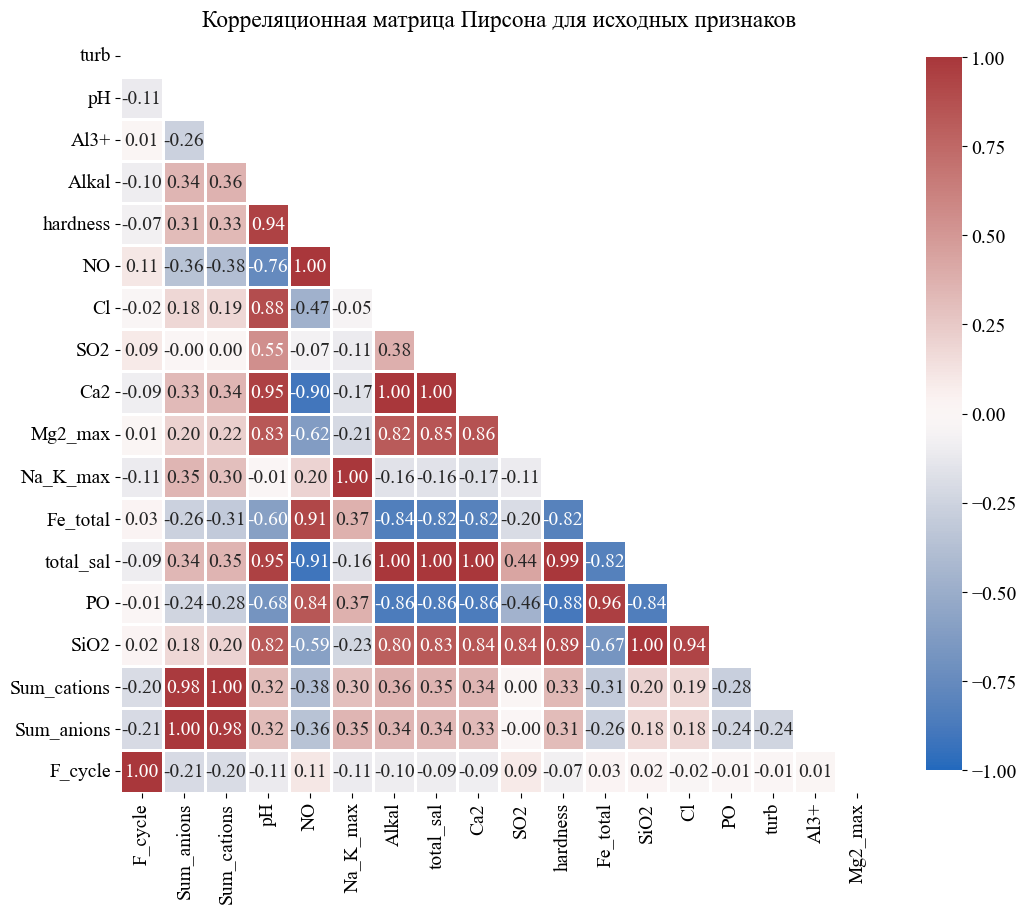

In [6]:
corr_matrix(df=df_F_cycle, target='F_cycle', method='pearson')

### kendall

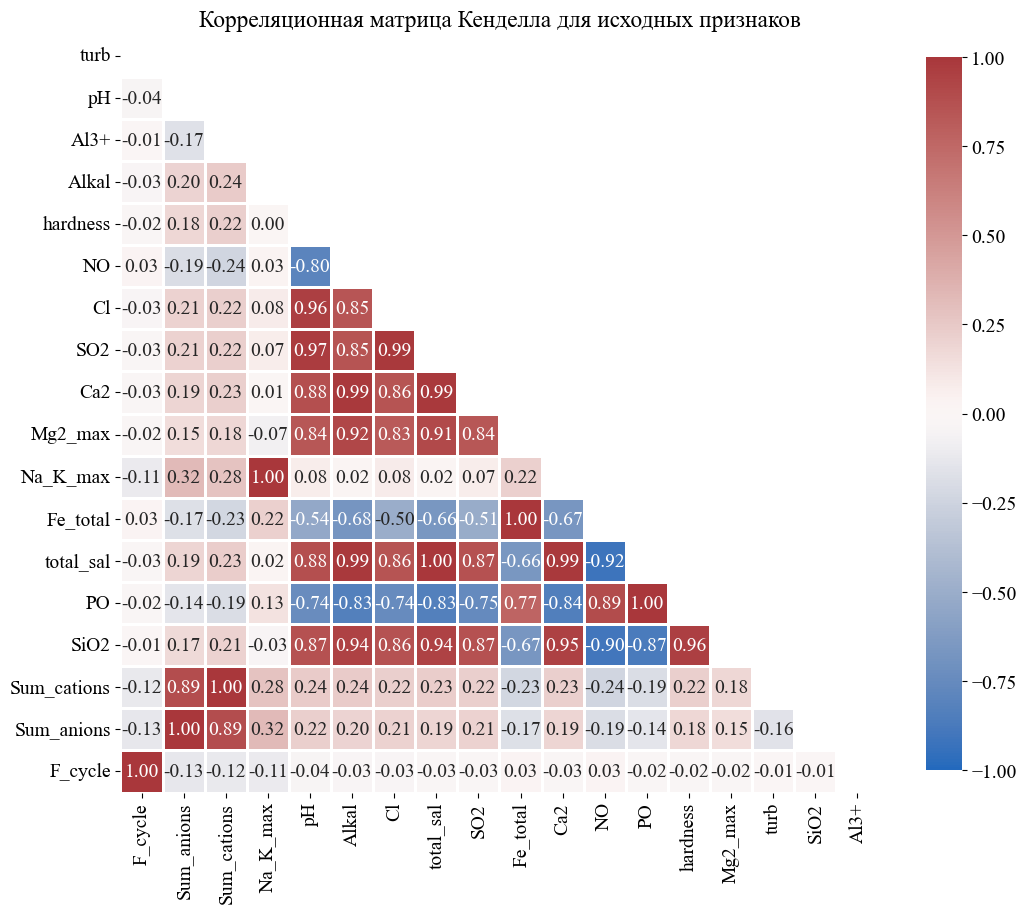

In [7]:
corr_matrix(df=df_F_cycle, target='F_cycle', method='kendall')

## Acid

In [8]:
df_Acid = df.copy()

# целевой признак
df_Acid['SpecG_acid'] = df_raw['SpecG_acid(eq)']
df_Acid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   turb         111 non-null    float64
 1   pH           111 non-null    float64
 2   Аl3+         111 non-null    float64
 3   Alkal        111 non-null    float64
 4   hardness     111 non-null    float64
 5   NO           111 non-null    float64
 6   Сl           111 non-null    float64
 7   SO2          111 non-null    float64
 8   Са2          111 non-null    float64
 9   Mg2_max      111 non-null    float64
 10  Na_K_max     111 non-null    float64
 11  Fe_total     111 non-null    float64
 12  total_sal    111 non-null    float64
 13  PO           111 non-null    float64
 14  SiO2         111 non-null    float64
 15  Sum_cations  111 non-null    float64
 16  Sum_anions   111 non-null    float64
 17  SpecG_acid   111 non-null    float64
dtypes: float64(18)
memory usage: 15.7 KB


### pearson

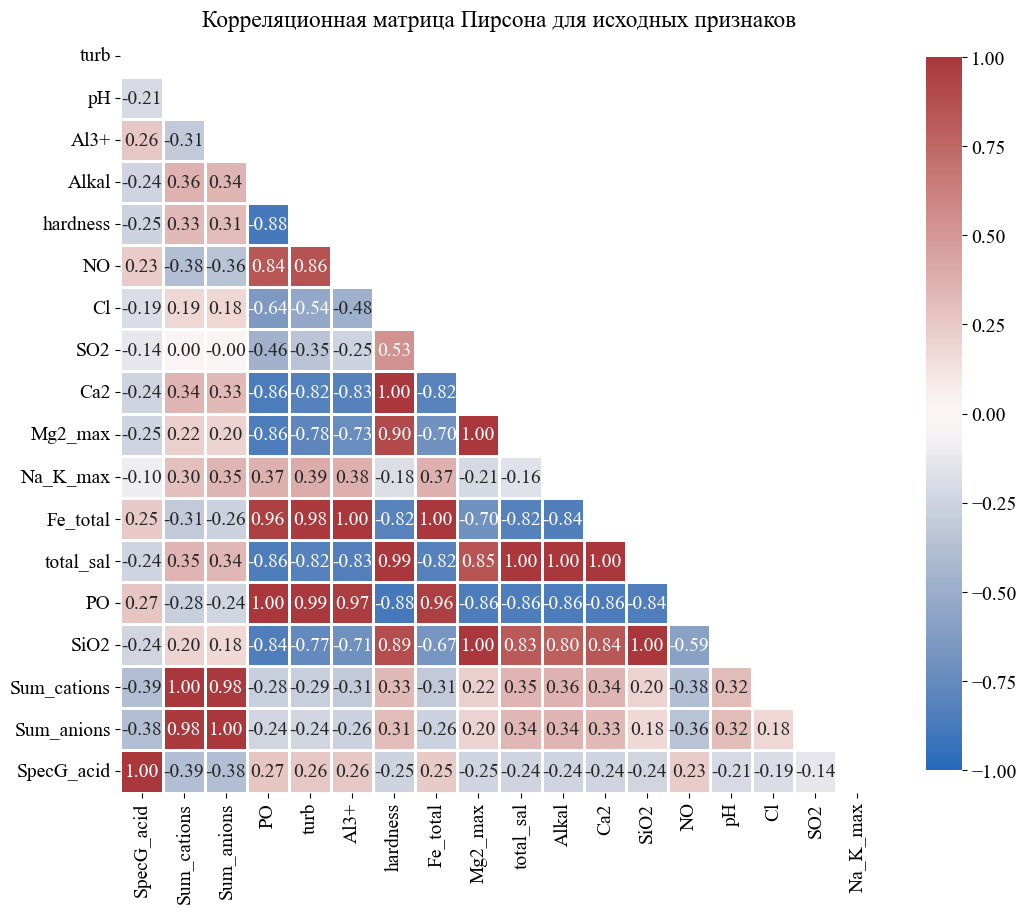

In [9]:
corr_matrix(df=df_Acid, target='SpecG_acid', method='pearson')

### kendall

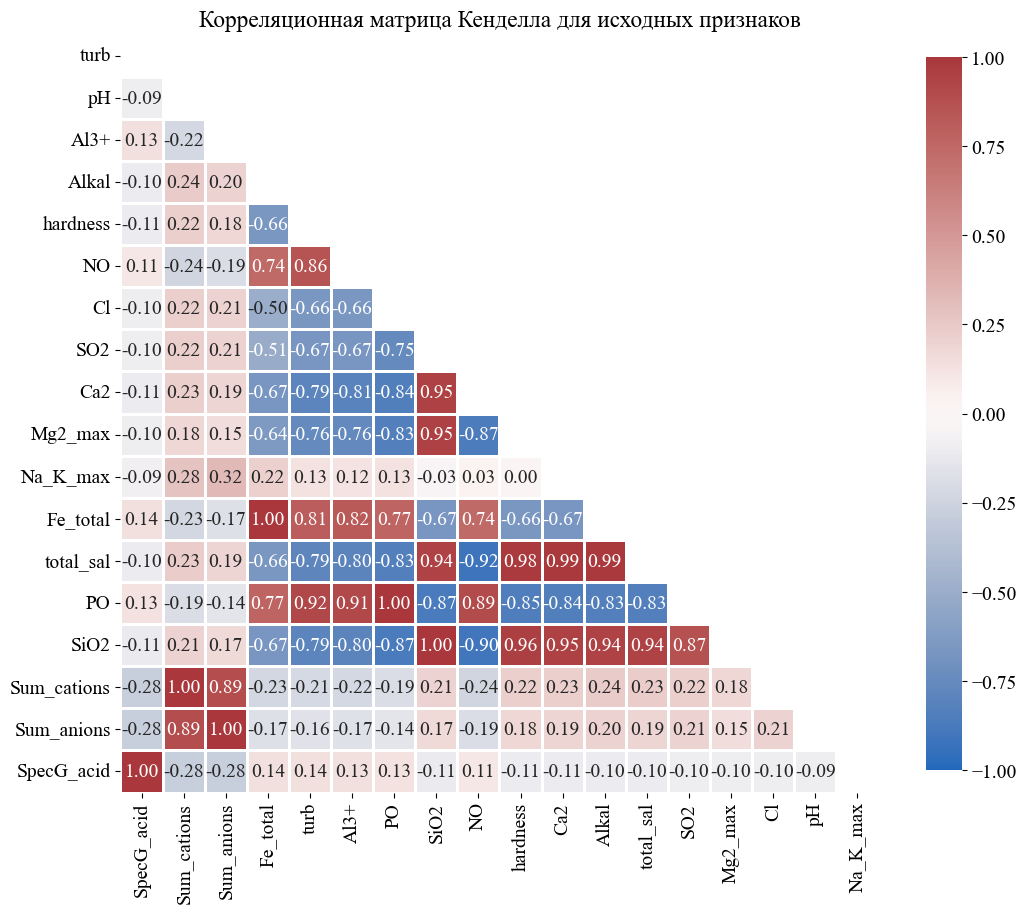

In [10]:
corr_matrix(df=df_Acid, target='SpecG_acid', method='kendall')

## Alcaline

In [11]:
df_Alcaline = df.copy()

# целевой признак
df_Alcaline['SpecG_alkali'] = df_raw['SpecG_alkali(eq)']
df_Alcaline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   turb          111 non-null    float64
 1   pH            111 non-null    float64
 2   Аl3+          111 non-null    float64
 3   Alkal         111 non-null    float64
 4   hardness      111 non-null    float64
 5   NO            111 non-null    float64
 6   Сl            111 non-null    float64
 7   SO2           111 non-null    float64
 8   Са2           111 non-null    float64
 9   Mg2_max       111 non-null    float64
 10  Na_K_max      111 non-null    float64
 11  Fe_total      111 non-null    float64
 12  total_sal     111 non-null    float64
 13  PO            111 non-null    float64
 14  SiO2          111 non-null    float64
 15  Sum_cations   111 non-null    float64
 16  Sum_anions    111 non-null    float64
 17  SpecG_alkali  111 non-null    float64
dtypes: float64(18)
memory usage: 1

### pearson

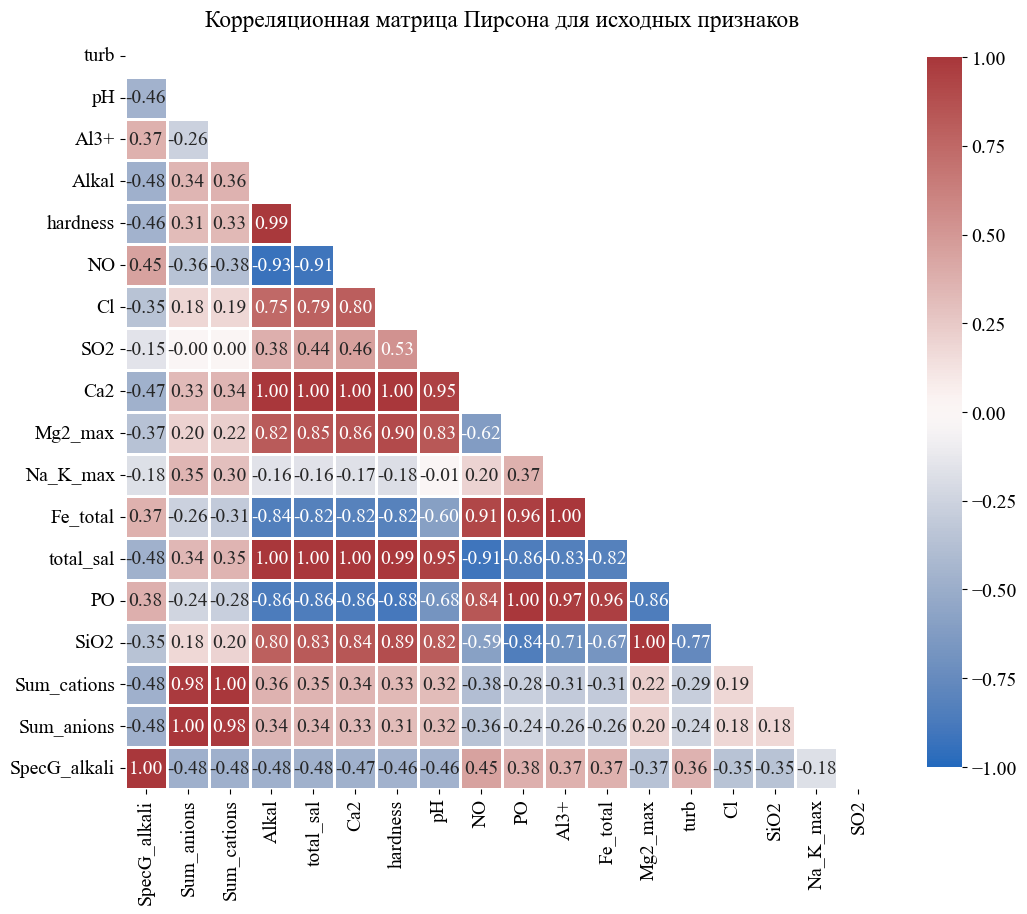

In [12]:
corr_matrix(df=df_Alcaline, target='SpecG_alkali', method='pearson')

### kendall

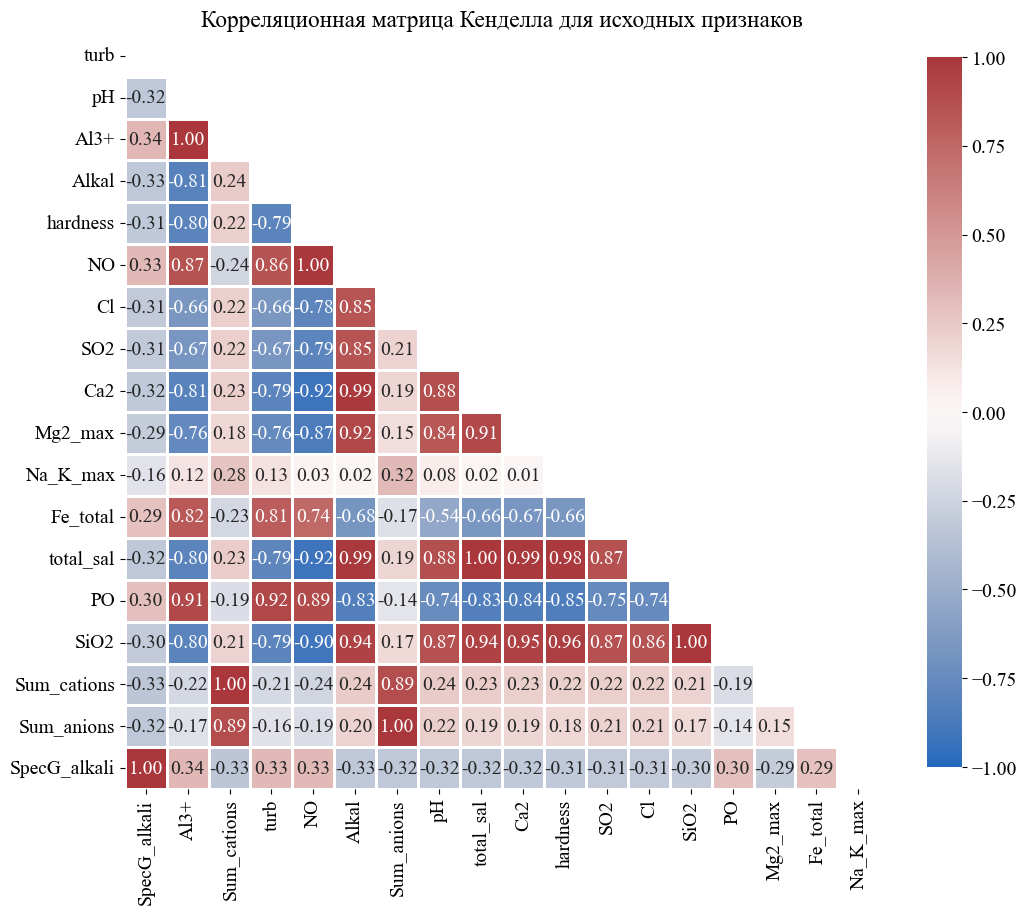

In [13]:
corr_matrix(df=df_Alcaline, target='SpecG_alkali', method='kendall')

# Feature important

In [31]:
def feature_importance_selector(X, y, engine='catboost'):
    
    if engine=='catboost':
        selector = catboost.CatBoostRegressor(silent=True)
    elif engine=='xgboost':
        selector = xgboost.XGBRegressor(random_state=42)
    
    selector.fit(X, y)

    feature_importances = pd.DataFrame({'importance' : selector.feature_importances_}, 
                                       index=X.columns).sort_values(by='importance', ascending=False)

    if engine=='catboost':
        feature_importances.importance /= 100
    
    plt.rcParams['font.size'] = 16
    plt.figure(figsize=(12, 5))
    
    for bar in plt.bar(range(len(feature_importances.index)), feature_importances.importance, align='center', width=0.8):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom')
    
    
    plt.xticks(range(len(feature_importances.index)), feature_importances.index, rotation=90)
    plt.ylim(0, (((feature_importances.importance.max()*100 // 5) + 2) * 5) / 100)

    plt.ylabel('Feature weight')
    plt.title(f'Features importance for {y.name}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'pictures/standard_feature_important_{y.name}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

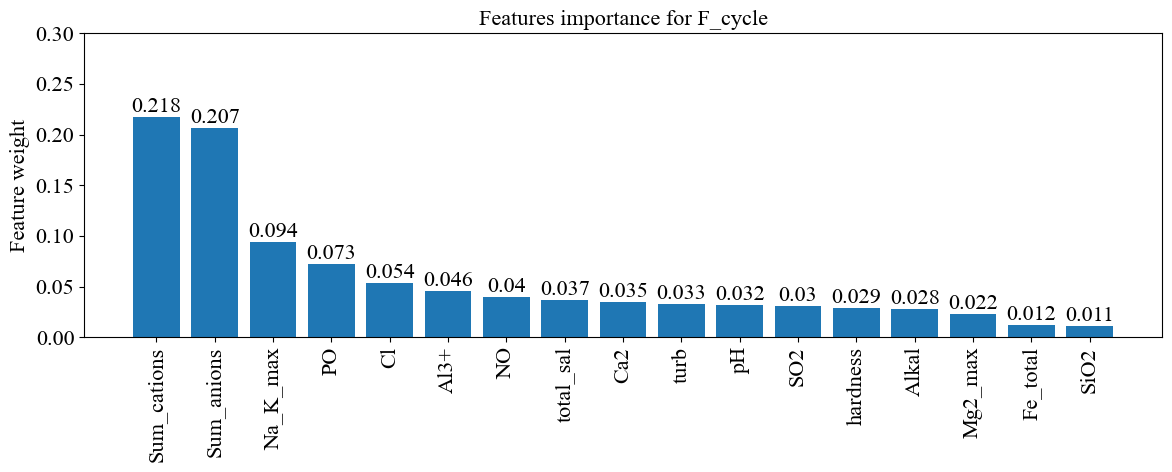

In [34]:
feature_importance_selector(X=df_F_cycle.drop(columns='F_cycle'), 
                            y=df_F_cycle.F_cycle, 
                            engine='catboost')

## Acid

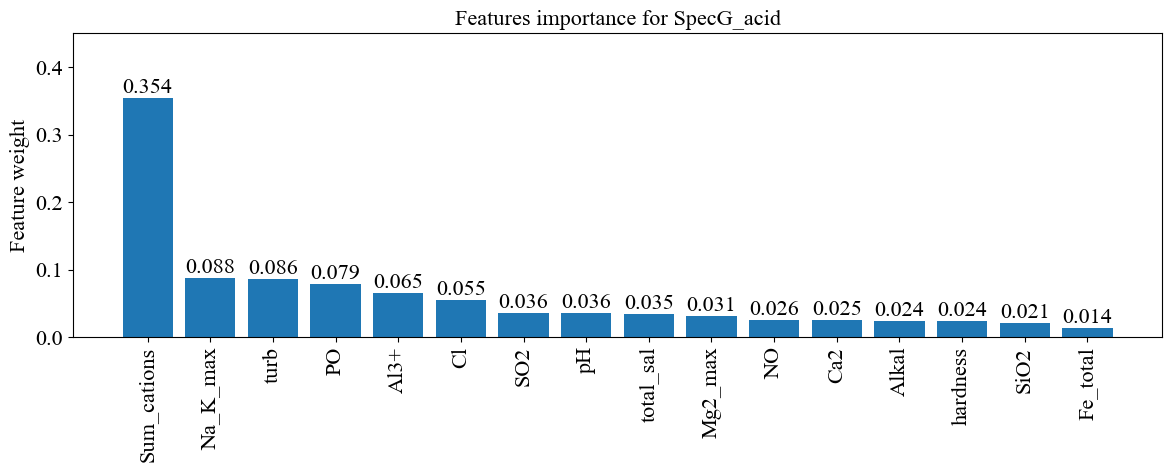

In [37]:
feature_importance_selector(X=df_Acid.drop(columns=['SpecG_acid', 'Sum_anions']), 
                            y=df_Acid.SpecG_acid, 
                            engine='catboost')

## Alcaline

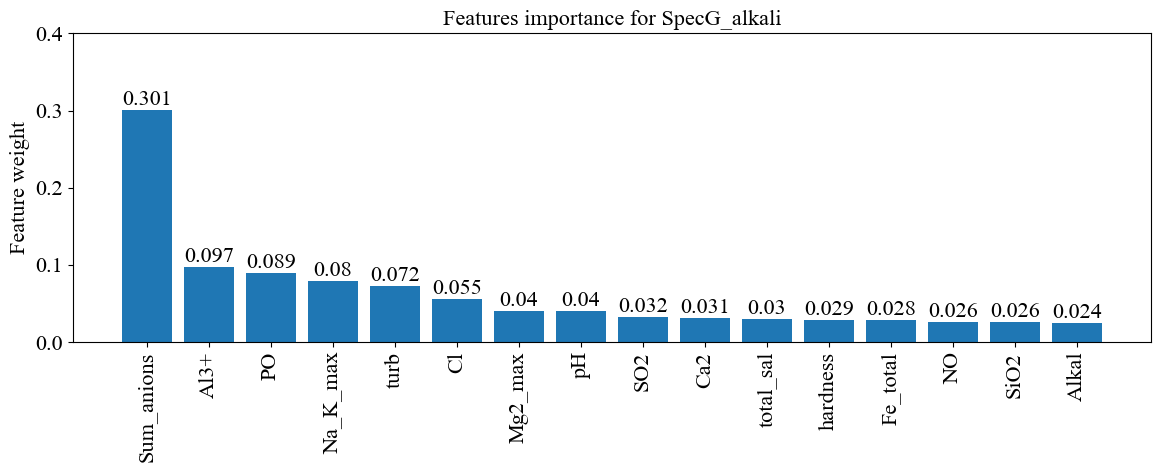

In [41]:
feature_importance_selector(X=df_Alcaline.drop(columns=['SpecG_alkali', 'Sum_cations']), 
                            y=df_Alcaline.SpecG_alkali,
                            engine='catboost')

# Pairplot

In [18]:
def pairplot(df, hue):
    plt.figure(figsize=(50,50))
    sns.pairplot(df, hue=hue, palette = "viridis")
    #plt.tight_layout()
    plt.savefig(f'pictures/pairlpot_{hue}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

<Figure size 5000x5000 with 0 Axes>

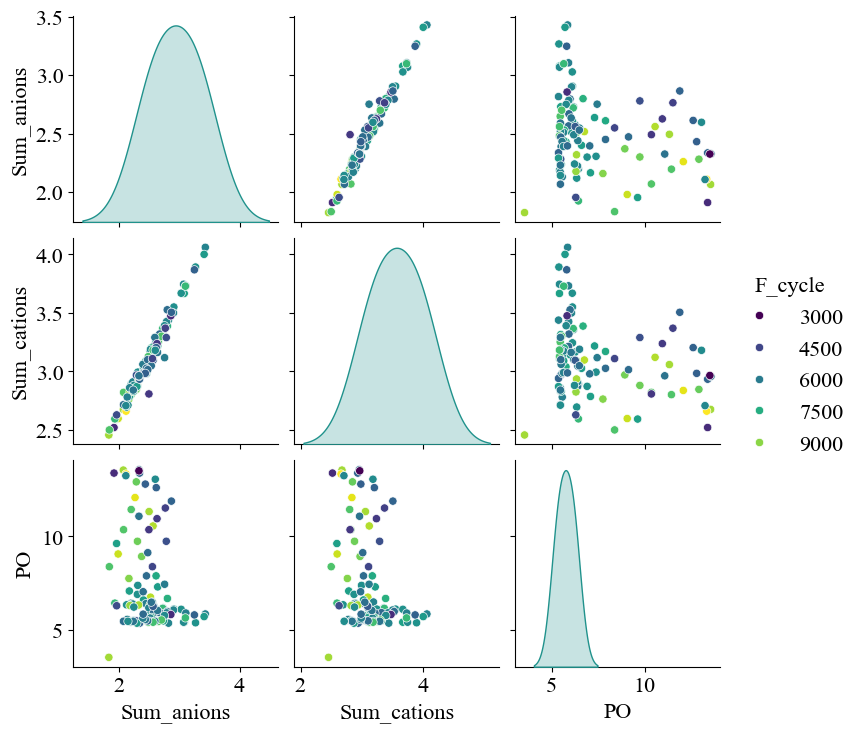

In [19]:
pairplot(df=df_F_cycle[['Sum_anions', 'Sum_cations', 'PO', 'F_cycle']], hue='F_cycle')

## Acid

<Figure size 5000x5000 with 0 Axes>

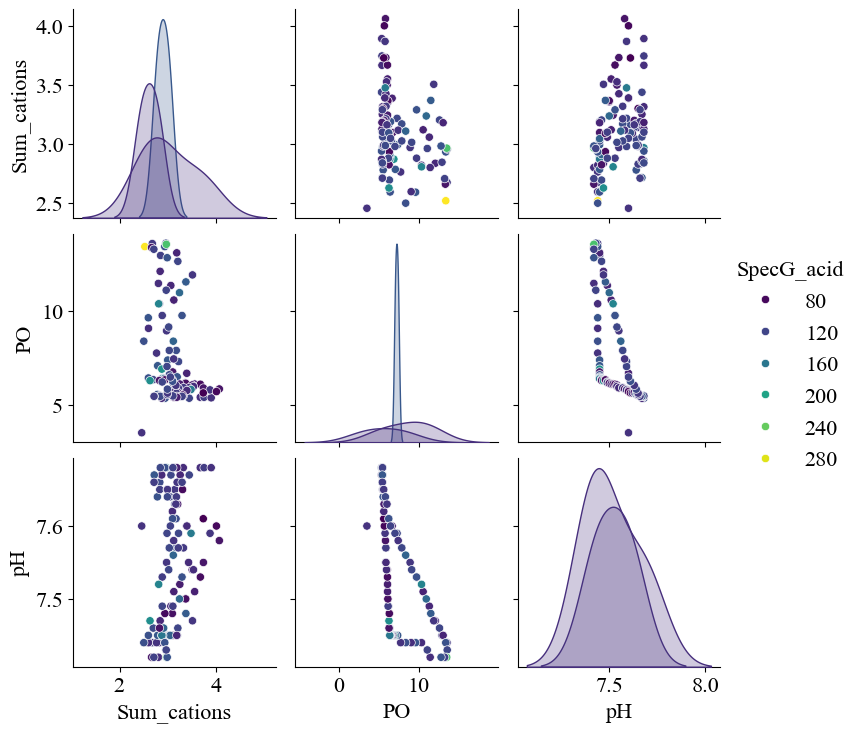

In [20]:
pairplot(df=df_Acid[['Sum_cations', 'PO', 'pH', 'SpecG_acid']], hue = 'SpecG_acid')

## Alcaline

<Figure size 5000x5000 with 0 Axes>

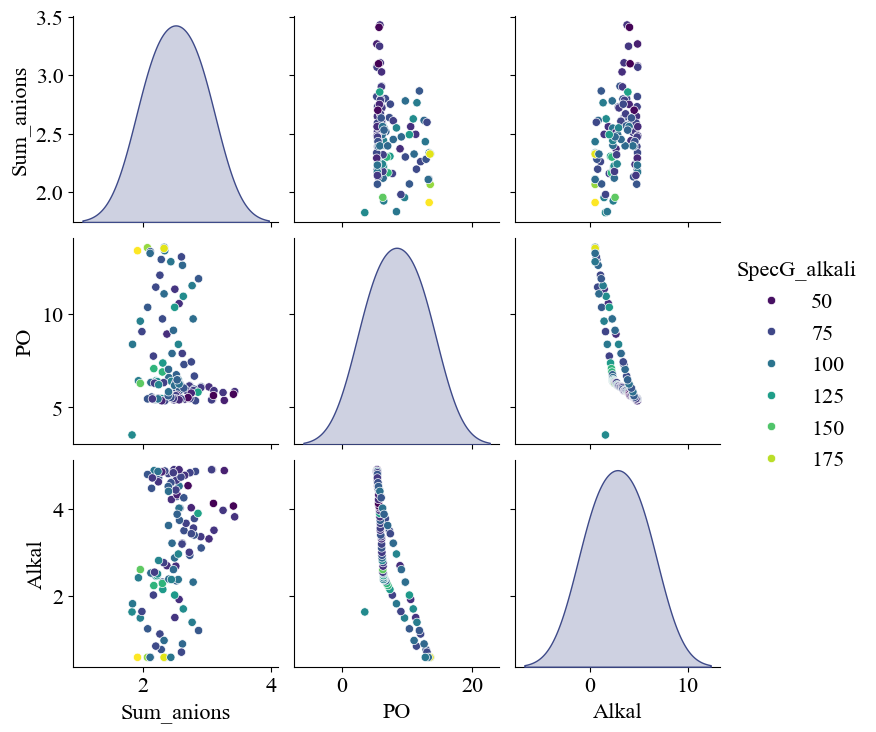

In [21]:
pairplot(df=df_Alcaline[['Sum_anions', 'PO', 'Alkal', 'SpecG_alkali']], hue = 'SpecG_alkali')